In [1]:
# ============================================================
# CELL 1 — INITIALIZE RED PITAYA / PYRPL
# ============================================================

import os
import time
import numpy as np
import matplotlib.pyplot as plt

from pyrpl import Pyrpl
from pyrpl.async_utils import wait


# ------------------------------------------------------------
# CONNECTION
# ------------------------------------------------------------

HOSTNAME = "rp-f0c970.local"

current_dir = os.path.dirname(os.path.abspath("."))
local_user_dir = os.path.join(current_dir, "pyrpl_data")

print("Connecting to Red Pitaya...")

p = Pyrpl(
    config="my_config",
    hostname=HOSTNAME,
    user_dir=local_user_dir,
    reloadfpga=True,
    gui=False,
)

rp = p.rp
asg = rp.asg0
scope = rp.scope

print("Connected.")


# ------------------------------------------------------------
# GENERAL HARDWARE SETTINGS
# ------------------------------------------------------------

# OUT1 -> laser DC modulation
asg.output_direct = "off"

# IN1 <- photodiode
scope.input1 = "in1"
scope.input2 = "off"

scope.ch1_active = True
scope.ch2_active = False

scope.average = False
scope.trace_average = 1

scope.run_continuous = False
scope.rolling_mode = False

# Largest decimation supported by your PyRPL installation.
scope.decimation = 65536

print()
print("ASG waveform memory:", asg.data_length, "points")
print("Scope samples:", scope.data_length)
print("Scope duration:", scope.duration, "s")

print()
print("Initialization complete.")

INFO:pyrpl:All your PyRPL settings will be saved to the config file
    /Users/brandon/pyrpl_user_dir/config/my_config.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe my_config" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('my_config')
in a python terminal.


Connecting to Red Pitaya...


INFO:pyrpl.redpitaya:Found FPGA binfile at: /Users/brandon/Documents/Python Scripts/RedPitaya/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.bin
INFO:pyrpl.redpitaya:Found DTBO file at: /Users/brandon/Documents/Python Scripts/RedPitaya/.venv/lib/python3.13/site-packages/pyrpl/fpga/red_pitaya.dtbo
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname rp-f0c970.local.


Connected.

ASG waveform memory: 16384 points
Scope samples: 16384
Scope duration: 8.589934592 s

Initialization complete.



COARSE LASER MODULATION SWEEP

Start voltage:    0.000 V
End voltage:      1.000 V
Sweep time:       2.000 s

ASG configured:
  Frequency: 0.500000 Hz
  Amplitude: 0.500000 V
  Offset:    0.500000 V

Arming photodiode acquisition...
Connecting ASG0 -> OUT1...
Starting coarse sweep...
Acquisition complete.

COARSE SWEEP COMPLETE
Samples:          16384
Voltage range:    0.0000 -> 1.0000 V
PD range:         0.313232 -> 0.448120 V


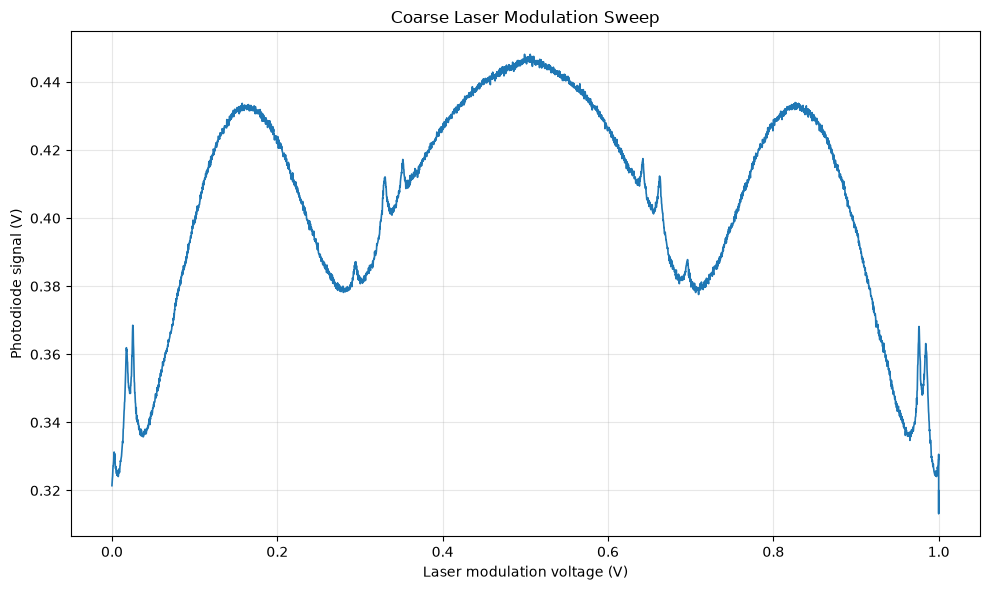

In [4]:
# ============================================================
# CELL 2 — COARSE SWEEP
# ============================================================

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

COARSE_START_V = 0
COARSE_END_V = 1

COARSE_SWEEP_TIME_S = 2.0


# ------------------------------------------------------------
# CHECK SETTINGS
# ------------------------------------------------------------

if not 0.0 <= COARSE_START_V <= 1.0:
    raise ValueError("COARSE_START_V must be between 0 and 1 V.")

if not 0.0 <= COARSE_END_V <= 1.0:
    raise ValueError("COARSE_END_V must be between 0 and 1 V.")

if COARSE_END_V <= COARSE_START_V:
    raise ValueError("COARSE_END_V must be greater than COARSE_START_V.")


print()
print("============================================================")
print("COARSE LASER MODULATION SWEEP")
print("============================================================")

print()
print(f"Start voltage:    {COARSE_START_V:.3f} V")
print(f"End voltage:      {COARSE_END_V:.3f} V")
print(f"Sweep time:       {COARSE_SWEEP_TIME_S:.3f} s")


# ------------------------------------------------------------
# MAP ACTUAL VOLTAGES TO ASG
# ------------------------------------------------------------

amplitude = (
    COARSE_END_V - COARSE_START_V
) / 2.0

offset = (
    COARSE_END_V + COARSE_START_V
) / 2.0

frequency = 1.0 / COARSE_SWEEP_TIME_S


# ------------------------------------------------------------
# CONFIGURE ASG
# ------------------------------------------------------------

asg.output_direct = "off"

asg.setup(
    waveform="ramp",
    frequency=frequency,
    amplitude=amplitude,
    offset=offset,
    trigger_source="immediately",
)

print()
print("ASG configured:")
print(f"  Frequency: {frequency:.6f} Hz")
print(f"  Amplitude: {amplitude:.6f} V")
print(f"  Offset:    {offset:.6f} V")


# ------------------------------------------------------------
# CONFIGURE SCOPE
# ------------------------------------------------------------

scope.input1 = "in1"
scope.input2 = "off"

scope.ch1_active = True
scope.ch2_active = False

scope.average = False
scope.trace_average = 1

scope.run_continuous = False
scope.rolling_mode = False

scope.trigger_source = "immediately"
scope.trigger_delay = 0


# ------------------------------------------------------------
# ARM SCOPE FIRST
# ------------------------------------------------------------

print()
print("Arming photodiode acquisition...")

scope_future = scope.single_async()

time.sleep(0.05)


# ------------------------------------------------------------
# START SWEEP
# ------------------------------------------------------------

print("Connecting ASG0 -> OUT1...")

asg.output_direct = "out1"

print("Starting coarse sweep...")


# ------------------------------------------------------------
# WAIT FOR ACQUISITION
# ------------------------------------------------------------

try:

    raw_data = wait(
        scope_future,
        timeout=scope.duration + 5.0,
    )

except Exception:

    asg.output_direct = "off"
    raise


print("Acquisition complete.")


# ------------------------------------------------------------
# EXTRACT IN1
# ------------------------------------------------------------

raw_data = np.asarray(raw_data, dtype=float)

if raw_data.ndim == 2:

    if raw_data.shape[0] == 2:
        coarse_pd = raw_data[0]

    elif raw_data.shape[1] == 2:
        coarse_pd = raw_data[:, 0]

    else:
        asg.output_direct = "off"
        raise RuntimeError(
            f"Unexpected scope data shape: {raw_data.shape}"
        )

elif raw_data.ndim == 1:

    coarse_pd = raw_data

else:

    asg.output_direct = "off"
    raise RuntimeError(
        f"Unexpected scope data shape: {raw_data.shape}"
    )

coarse_pd = np.asarray(coarse_pd).reshape(-1)


# ------------------------------------------------------------
# TIME AXIS
# ------------------------------------------------------------

coarse_time = np.asarray(
    scope.times,
    dtype=float,
).reshape(-1)

coarse_time -= coarse_time[0]


if len(coarse_time) != len(coarse_pd):
    asg.output_direct = "off"
    raise RuntimeError(
        "Time/data length mismatch."
    )


# ------------------------------------------------------------
# CONVERT TIME -> LASER VOLTAGE
# ------------------------------------------------------------

coarse_voltage = (
    COARSE_START_V
    + (
        COARSE_END_V
        - COARSE_START_V
    )
    * coarse_time
    / COARSE_SWEEP_TIME_S
)

coarse_voltage = np.clip(
    coarse_voltage,
    COARSE_START_V,
    COARSE_END_V,
)


# ------------------------------------------------------------
# STOP OUTPUT
# ------------------------------------------------------------

asg.output_direct = "off"


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print()
print("============================================================")
print("COARSE SWEEP COMPLETE")
print("============================================================")

print(f"Samples:          {len(coarse_pd)}")
print(
    f"Voltage range:    "
    f"{coarse_voltage[0]:.4f} -> "
    f"{coarse_voltage[-1]:.4f} V"
)

print(
    f"PD range:         "
    f"{np.min(coarse_pd):.6f} -> "
    f"{np.max(coarse_pd):.6f} V"
)


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    coarse_voltage,
    coarse_pd,
    linewidth=1.2,
)

plt.xlabel("Laser modulation voltage (V)")
plt.ylabel("Photodiode signal (V)")

plt.title("Coarse Laser Modulation Sweep")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


FINE LASER MODULATION SWEEP

Center voltage:   0.6300 V
Range:             0.1000 V
Start voltage:     0.5800 V
End voltage:       0.6800 V
Sweep time:        10.000 s

ASG configured:
  Frequency: 0.100000 Hz
  Amplitude: 0.050000 V
  Offset:    0.630000 V

Arming photodiode acquisition...
Connecting ASG0 -> OUT1...
Starting fine sweep...
Acquisition complete.

FINE SWEEP COMPLETE
Samples:          16384
Voltage range:    0.58000 -> 0.66589 V
PD range:         0.368896 -> 0.398193 V

Fine-scan maximum:
  Voltage:         0.622347 V
  PD signal:       0.398193 V


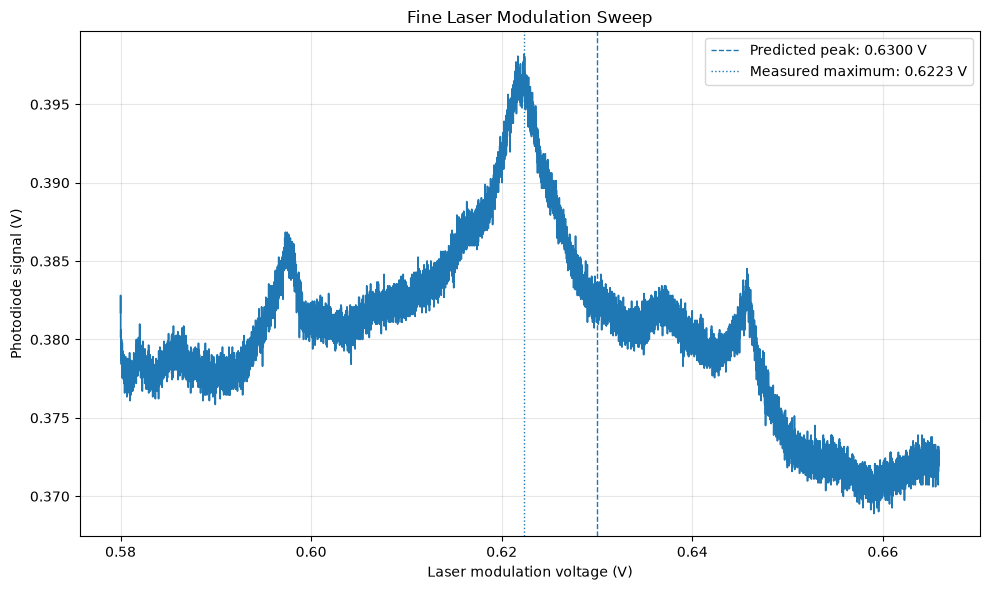

In [5]:
# ============================================================
# CELL 3 — FINE SWEEP
# ============================================================

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

FINE_CENTER_V = 0.63

# TOTAL voltage width of the fine scan.
#
# Example:
#   center = 0.63 V
#   range  = 0.10 V
#
# gives:
#   0.58 V -> 0.68 V
#
FINE_RANGE_V = 0.10

FINE_SWEEP_TIME_S = 10.0


# ------------------------------------------------------------
# CALCULATE ENDPOINTS
# ------------------------------------------------------------

FINE_START_V = (
    FINE_CENTER_V
    - FINE_RANGE_V / 2.0
)

FINE_END_V = (
    FINE_CENTER_V
    + FINE_RANGE_V / 2.0
)


# ------------------------------------------------------------
# CHECK SETTINGS
# ------------------------------------------------------------

if FINE_RANGE_V <= 0:
    raise ValueError(
        "FINE_RANGE_V must be greater than zero."
    )

if FINE_START_V < 0.0:
    raise ValueError(
        f"Fine sweep starts at {FINE_START_V:.3f} V, "
        "which is below the Red Pitaya output limit."
    )

if FINE_END_V > 1.0:
    raise ValueError(
        f"Fine sweep ends at {FINE_END_V:.3f} V, "
        "which exceeds the 1 V limit."
    )


print()
print("============================================================")
print("FINE LASER MODULATION SWEEP")
print("============================================================")

print()
print(f"Center voltage:   {FINE_CENTER_V:.4f} V")
print(f"Range:             {FINE_RANGE_V:.4f} V")
print(f"Start voltage:     {FINE_START_V:.4f} V")
print(f"End voltage:       {FINE_END_V:.4f} V")
print(f"Sweep time:        {FINE_SWEEP_TIME_S:.3f} s")


# ------------------------------------------------------------
# MAP VOLTAGE RANGE TO ASG
# ------------------------------------------------------------

amplitude = (
    FINE_END_V - FINE_START_V
) / 2.0

offset = (
    FINE_END_V + FINE_START_V
) / 2.0

frequency = 1.0 / FINE_SWEEP_TIME_S


# ------------------------------------------------------------
# CONFIGURE ASG
# ------------------------------------------------------------

asg.output_direct = "off"

asg.setup(
    waveform="ramp",
    frequency=frequency,
    amplitude=amplitude,
    offset=offset,
    trigger_source="immediately",
)

print()
print("ASG configured:")
print(f"  Frequency: {frequency:.6f} Hz")
print(f"  Amplitude: {amplitude:.6f} V")
print(f"  Offset:    {offset:.6f} V")


# ------------------------------------------------------------
# CONFIGURE SCOPE
# ------------------------------------------------------------

scope.input1 = "in1"
scope.input2 = "off"

scope.ch1_active = True
scope.ch2_active = False

scope.average = False
scope.trace_average = 1

scope.run_continuous = False
scope.rolling_mode = False

scope.trigger_source = "immediately"
scope.trigger_delay = 0


# ------------------------------------------------------------
# ARM SCOPE
# ------------------------------------------------------------

print()
print("Arming photodiode acquisition...")

scope_future = scope.single_async()

time.sleep(0.05)


# ------------------------------------------------------------
# START FINE SWEEP
# ------------------------------------------------------------

print("Connecting ASG0 -> OUT1...")

asg.output_direct = "out1"

print("Starting fine sweep...")


# ------------------------------------------------------------
# WAIT FOR ACQUISITION
# ------------------------------------------------------------

try:

    raw_data = wait(
        scope_future,
        timeout=scope.duration + 5.0,
    )

except Exception:

    asg.output_direct = "off"
    raise


print("Acquisition complete.")


# ------------------------------------------------------------
# EXTRACT IN1
# ------------------------------------------------------------

raw_data = np.asarray(raw_data, dtype=float)

if raw_data.ndim == 2:

    if raw_data.shape[0] == 2:
        fine_pd = raw_data[0]

    elif raw_data.shape[1] == 2:
        fine_pd = raw_data[:, 0]

    else:
        asg.output_direct = "off"
        raise RuntimeError(
            f"Unexpected scope data shape: {raw_data.shape}"
        )

elif raw_data.ndim == 1:

    fine_pd = raw_data

else:

    asg.output_direct = "off"
    raise RuntimeError(
        f"Unexpected scope data shape: {raw_data.shape}"
    )

fine_pd = np.asarray(fine_pd).reshape(-1)


# ------------------------------------------------------------
# TIME AXIS
# ------------------------------------------------------------

fine_time = np.asarray(
    scope.times,
    dtype=float,
).reshape(-1)

fine_time -= fine_time[0]


if len(fine_time) != len(fine_pd):
    asg.output_direct = "off"
    raise RuntimeError(
        "Time/data length mismatch."
    )


# ------------------------------------------------------------
# CONVERT TIME -> LASER VOLTAGE
# ------------------------------------------------------------

fine_voltage = (
    FINE_START_V
    + (
        FINE_END_V
        - FINE_START_V
    )
    * fine_time
    / FINE_SWEEP_TIME_S
)

fine_voltage = np.clip(
    fine_voltage,
    FINE_START_V,
    FINE_END_V,
)


# ------------------------------------------------------------
# STOP OUTPUT
# ------------------------------------------------------------

asg.output_direct = "off"


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print()
print("============================================================")
print("FINE SWEEP COMPLETE")
print("============================================================")

print(f"Samples:          {len(fine_pd)}")

print(
    f"Voltage range:    "
    f"{fine_voltage[0]:.5f} -> "
    f"{fine_voltage[-1]:.5f} V"
)

print(
    f"PD range:         "
    f"{np.min(fine_pd):.6f} -> "
    f"{np.max(fine_pd):.6f} V"
)


# ------------------------------------------------------------
# FIND MAXIMUM
# ------------------------------------------------------------

peak_index = np.argmax(fine_pd)

peak_voltage = fine_voltage[peak_index]
peak_signal = fine_pd[peak_index]

print()
print("Fine-scan maximum:")
print(f"  Voltage:         {peak_voltage:.6f} V")
print(f"  PD signal:       {peak_signal:.6f} V")


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    fine_voltage,
    fine_pd,
    linewidth=1.2,
)

plt.axvline(
    FINE_CENTER_V,
    linestyle="--",
    linewidth=1,
    label=f"Predicted peak: {FINE_CENTER_V:.4f} V",
)

plt.axvline(
    peak_voltage,
    linestyle=":",
    linewidth=1,
    label=f"Measured maximum: {peak_voltage:.4f} V",
)

plt.xlabel("Laser modulation voltage (V)")
plt.ylabel("Photodiode signal (V)")

plt.title("Fine Laser Modulation Sweep")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()